<a href="https://colab.research.google.com/github/guhmtzz/CIAO_GUSTAVO_2026/blob/main/Aula_4_exercicio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


RESULTADOS - DESAFIO 03: BALANCEAMENTO DE CARGA
Alocacao encontrada (tarefa -> servidor): [1 1 2 2 0 0 1 3 2 1 3 2 3 0 3 0 0 1 0 1]

  Servidor 0: tarefas [4, 5, 13, 15, 16, 18] | carga = 135s
  Servidor 1: tarefas [0, 1, 6, 9, 17, 19] | carga = 136s
  Servidor 2: tarefas [2, 3, 8, 11] | carga = 136s
  Servidor 3: tarefas [7, 10, 12, 14] | carga = 134s

Soma total de trabalho: 541s
Carga ideal por servidor (limite teorico minimo): 135.25s
Makespan encontrado (fitness final): 136s
Tempo de execucao do AG: 9179.46 ms


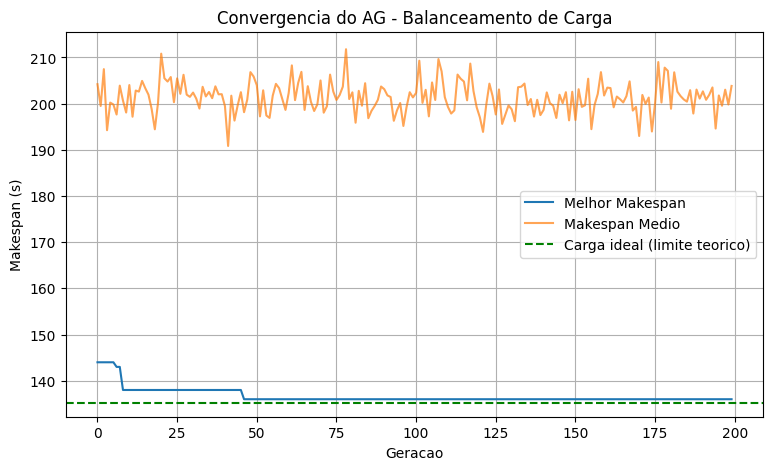

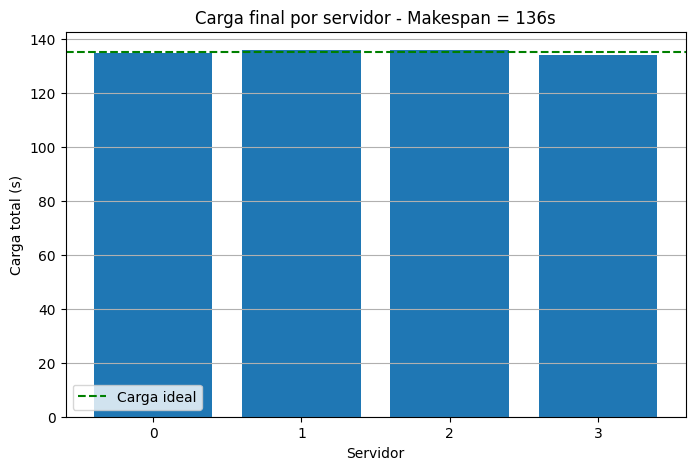

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ============================================================
# DESAFIO 03 — BALANCEAMENTO DE CARGA EM SERVIDORES
# ============================================================
#
# Cenario: 20 tarefas devem ser distribuidas entre 4 servidores.
# Objetivo: minimizar o MAKESPAN (tempo do servidor mais sobrecarregado).
#
# Representacao do individuo: vetor de 20 posicoes com inteiros em [0,3],
# onde indice = tarefa e valor = servidor atribuido.
# Ex.: individuo = [0, 2, 1, 0, 3, ...] -> tarefa 0 no servidor 0,
#      tarefa 1 no servidor 2, tarefa 2 no servidor 1, etc.
#
# Observacao importante: como cada gene e independente (nao ha restricao
# de permutacao, diferente do problema de rotas do Exercicio 1), crossover
# de dois pontos / uniforme e mutacao por "flip" de gene sao suficientes e
# validos aqui. Nao ha necessidade de OX/Swap, que servem especificamente
# para preservar permutacoes.

np.random.seed(7)

# ------------------------------------------------------------
# 1. DADOS DO PROBLEMA
# ------------------------------------------------------------

TEMPOS_TAREFAS = np.array(
    [12, 35, 40, 8, 15, 22, 19, 45, 60, 31,
     14, 28, 50, 18, 25, 33, 42, 10, 5, 29]
)

NUM_TAREFAS = len(TEMPOS_TAREFAS)      # 20
NUM_SERVIDORES = 4

TAMANHO_POPULACAO = 80
NUM_GERACOES = 200
TAXA_MUTACAO = 0.25   # probabilidade de mutar CADA gene (mutacao por gene)


# ------------------------------------------------------------
# 2. FUNCAO DE FITNESS (MAKESPAN)
# ------------------------------------------------------------

def calcular_carga_servidores(individuo, tempos, num_servidores):
    """
    Retorna um vetor com a carga total (soma dos tempos) de cada servidor,
    dado o vetor de alocacao (individuo).
    """
    cargas = np.zeros(num_servidores)
    for tarefa, servidor in enumerate(individuo):
        cargas[servidor] += tempos[tarefa]
    return cargas


def calcular_makespan(individuo, tempos, num_servidores):
    """
    Fitness = Makespan = maior carga acumulada entre os servidores.
    Quanto menor, melhor (minimizacao).
    """
    cargas = calcular_carga_servidores(individuo, tempos, num_servidores)
    return np.max(cargas)


# ------------------------------------------------------------
# 3. CRIACAO DA POPULACAO INICIAL
# ------------------------------------------------------------

def criar_populacao(tamanho_populacao, num_tarefas, num_servidores):
    """
    Cada individuo e um vetor de NUM_TAREFAS inteiros aleatorios em [0, num_servidores-1].
    Diferente do problema de rotas, aqui NAO usamos permutacao:
    varias tarefas podem (e devem) ir para o mesmo servidor.
    """
    return [
        np.random.randint(0, num_servidores, size=num_tarefas)
        for _ in range(tamanho_populacao)
    ]


# ------------------------------------------------------------
# 4. CROSSOVER DE DOIS PONTOS
# ------------------------------------------------------------

def crossover_dois_pontos(pai1, pai2):
    """
    Crossover classico de dois pontos: nao ha restricao de permutacao aqui,
    entao um crossover simples ja preserva individuos validos.
    """
    tamanho = len(pai1)
    ponto1, ponto2 = sorted(np.random.choice(tamanho, 2, replace=False))

    filho = pai1.copy()
    filho[ponto1:ponto2] = pai2[ponto1:ponto2]

    return filho


# ------------------------------------------------------------
# 5. MUTACAO POR REALOCACAO DE TAREFA
# ------------------------------------------------------------

def mutacao_realocacao(individuo, taxa_mutacao, num_servidores):
    """
    Para cada gene (tarefa), com probabilidade `taxa_mutacao`,
    reatribui a tarefa a um servidor aleatorio diferente do atual.
    """
    individuo = individuo.copy()
    for tarefa in range(len(individuo)):
        if np.random.rand() < taxa_mutacao:
            servidor_atual = individuo[tarefa]
            opcoes = [s for s in range(num_servidores) if s != servidor_atual]
            individuo[tarefa] = np.random.choice(opcoes)
    return individuo


# ------------------------------------------------------------
# 6. SELECAO POR TORNEIO
# ------------------------------------------------------------

def selecao_torneio(populacao, fitness, tamanho_torneio=3):
    participantes = np.random.choice(len(populacao), tamanho_torneio, replace=False)
    melhor = participantes[np.argmin([fitness[i] for i in participantes])]
    return populacao[melhor]


# ------------------------------------------------------------
# 7. EXECUCAO DO ALGORITMO GENETICO
# ------------------------------------------------------------

populacao = criar_populacao(TAMANHO_POPULACAO, NUM_TAREFAS, NUM_SERVIDORES)

historico_melhor = []
historico_medio = []

melhor_individuo_global = None
melhor_makespan_global = np.inf

tempo_inicio = time.time()

for geracao in range(NUM_GERACOES):

    # Avaliacao
    fitness_populacao = [
        calcular_makespan(ind, TEMPOS_TAREFAS, NUM_SERVIDORES)
        for ind in populacao
    ]

    indice_melhor = np.argmin(fitness_populacao)
    melhor_ind_geracao = populacao[indice_melhor].copy()
    melhor_fit_geracao = fitness_populacao[indice_melhor]

    if melhor_fit_geracao < melhor_makespan_global:
        melhor_makespan_global = melhor_fit_geracao
        melhor_individuo_global = melhor_ind_geracao.copy()

    historico_melhor.append(melhor_makespan_global)
    historico_medio.append(np.mean(fitness_populacao))

    # Elitismo
    nova_populacao = [melhor_individuo_global.copy()]

    # Reproducao
    while len(nova_populacao) < TAMANHO_POPULACAO:
        pai1 = selecao_torneio(populacao, fitness_populacao)
        pai2 = selecao_torneio(populacao, fitness_populacao)

        filho = crossover_dois_pontos(pai1, pai2)
        filho = mutacao_realocacao(filho, TAXA_MUTACAO, NUM_SERVIDORES)

        nova_populacao.append(filho)

    populacao = nova_populacao

tempo_fim = time.time()


# ------------------------------------------------------------
# 8. RESULTADOS
# ------------------------------------------------------------

cargas_finais = calcular_carga_servidores(melhor_individuo_global, TEMPOS_TAREFAS, NUM_SERVIDORES)
makespan_final = np.max(cargas_finais)
soma_total = np.sum(TEMPOS_TAREFAS)
carga_ideal = soma_total / NUM_SERVIDORES
tempo_execucao = (tempo_fim - tempo_inicio) * 1000

print("\n" + "=" * 60)
print("RESULTADOS - DESAFIO 03: BALANCEAMENTO DE CARGA")
print("=" * 60)
print(f"Alocacao encontrada (tarefa -> servidor): {melhor_individuo_global}")
print()
for s in range(NUM_SERVIDORES):
    tarefas_do_servidor = [i for i, srv in enumerate(melhor_individuo_global) if srv == s]
    print(f"  Servidor {s}: tarefas {tarefas_do_servidor} | carga = {cargas_finais[s]:.0f}s")
print()
print(f"Soma total de trabalho: {soma_total}s")
print(f"Carga ideal por servidor (limite teorico minimo): {carga_ideal:.2f}s")
print(f"Makespan encontrado (fitness final): {makespan_final:.0f}s")
print(f"Tempo de execucao do AG: {tempo_execucao:.2f} ms")
print("=" * 60)


# ------------------------------------------------------------
# 9. GRAFICO DE CONVERGENCIA
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.plot(historico_melhor, label="Melhor Makespan")
plt.plot(historico_medio, label="Makespan Medio", alpha=0.7)
plt.axhline(carga_ideal, color="green", linestyle="--", label="Carga ideal (limite teorico)")
plt.title("Convergencia do AG - Balanceamento de Carga")
plt.xlabel("Geracao")
plt.ylabel("Makespan (s)")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 10. GRAFICO DE CARGA POR SERVIDOR
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.bar(range(NUM_SERVIDORES), cargas_finais, color="tab:blue")
plt.axhline(carga_ideal, color="green", linestyle="--", label="Carga ideal")
plt.title(f"Carga final por servidor - Makespan = {makespan_final:.0f}s")
plt.xlabel("Servidor")
plt.ylabel("Carga total (s)")
plt.xticks(range(NUM_SERVIDORES))
plt.legend()
plt.grid(True, axis="y")
plt.show()